# ARIMA Baseline Forecasting

Capstone Project - Time Series Analysis 2026

## 0. Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pmdarima import auto_arima
from statsmodels.stats.diagnostic import acorr_ljungbox

import os

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

os.makedirs('../outputs/forecasts', exist_ok=True)
os.makedirs('../outputs/plots',     exist_ok=True)

print('Imports OK.')

Imports OK.


In [2]:
TICKERS = {
    'Banking' : 'HDFCBANK.NS',
    'IT'      : 'INFY.NS',
    'Pharma'  : 'SUNPHARMA.NS',
    'FMCG'    : 'HINDUNILVR.NS'
}

TICKER_LIST      = list(TICKERS.values())
SECTOR_MAP       = {v: k for k, v in TICKERS.items()}
FORECAST_HORIZON = 2   # two trading days beyond dataset

---
## 1. Load Processed Data from Notebook 01

In [3]:
train_close = pd.read_csv('../data/processed/train_close.csv', index_col=0, parse_dates=True)
test_close  = pd.read_csv('../data/processed/test_close.csv',  index_col=0, parse_dates=True)

print(f'Train: {train_close.index[0].date()} → {train_close.index[-1].date()}  ({len(train_close)} rows)')
print(f'Test : {test_close.index[0].date()}  → {test_close.index[-1].date()}  ({len(test_close)} rows)')
train_close.head(3)

Train: 2021-01-01 → 2025-06-30  (1110 rows)
Test : 2025-07-01  → 2025-12-30  (125 rows)


,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,SUNPHARMA.NS
Date,,,,
2021-01-01,674.886414,2195.603760,1109.599609,562.592773
2021-01-04,670.600342,2231.422363,1134.072632,570.282898
2021-01-05,675.667664,2253.539062,1138.958496,569.386414


---
## 2. Metric Helper Functions

In [4]:
def mape(actual, predicted):
    """Mean Absolute Percentage Error — lower is better."""
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def rmse(actual, predicted):
    """Root Mean Squared Error — lower is better."""
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted)) ** 2))

def directional_accuracy(actual, predicted):
    """
    What % of the time did the model correctly predict up vs down?
    Computed on consecutive differences (direction of movement).
    """
    actual    = np.array(actual)
    predicted = np.array(predicted)
    actual_dir    = np.sign(np.diff(actual))
    predicted_dir = np.sign(np.diff(predicted))
    correct = np.sum(actual_dir == predicted_dir)
    return (correct / len(actual_dir)) * 100

print('Metric functions ready.')

Metric functions ready.


---
## 3. ARIMA — Train, Evaluate, Forecast

**How ARIMA works (minimum understanding):**
- **AR(p):** uses last p values to predict next value
- **I(d):** differences the series d times to make it stationary (d=1 for stock prices)
- **MA(q):** uses last q forecast errors to correct predictions
- **auto_arima** searches for the best (p, d, q) using AIC/BIC — you don't pick these manually

**Strategy:** train on raw close prices (auto_arima handles differencing internally via d parameter)

In [7]:
arima_models   = {}   # store fitted models
arima_metrics  = []   # store evaluation results
arima_test_preds = {} # store test set predictions

for ticker in TICKER_LIST:
    print(f'\n{"="*50}')
    print(f'Fitting ARIMA for: {ticker} ({SECTOR_MAP[ticker]})')
    print('='*50)

    train_series = train_close[ticker].dropna()
    test_series  = test_close[ticker].dropna()

    model = auto_arima(
        train_series,
        d=1,
        max_p=5, max_q=5,
        seasonal=False,
        stepwise=True,
        information_criterion='aic',
        error_action='ignore',
        suppress_warnings=True
    )

    print(f'Best order: {model.order}  |  AIC: {model.aic():.2f}')
    arima_models[ticker] = model
    
    # Step 2: predict entire test horizon in ONE call — no updating on test data
    
    n_test = len(test_series)
    predictions = np.asarray(model.predict(n_periods=n_test)).ravel()
    arima_test_preds[ticker] = predictions

    actual = test_series.values
    m = {
        'Stock'    : ticker,
        'Sector'   : SECTOR_MAP[ticker],
        'Order'    : str(model.order),
        'MAPE (%)'  : round(mape(actual, predictions), 4),
        'RMSE'      : round(rmse(actual, predictions), 4),
        'Dir Acc (%)': round(directional_accuracy(actual, predictions), 2)
    }
    arima_metrics.append(m)
    print(f'  MAPE: {m["MAPE (%)"]:.2f}%  |  RMSE: {m["RMSE"]:.2f}  |  Dir Acc: {m["Dir Acc (%)"]:.1f}%')

print('\nAll ARIMA models done.')


Fitting ARIMA for: HDFCBANK.NS (Banking)
Best order: (2, 1, 2)  |  AIC: 8354.54
  MAPE: 1.44%  |  RMSE: 19.50  |  Dir Acc: 47.6%

Fitting ARIMA for: INFY.NS (IT)


/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Best order: (0, 1, 0)  |  AIC: 10059.55
  MAPE: 5.41%  |  RMSE: 93.74  |  Dir Acc: 0.8%

Fitting ARIMA for: SUNPHARMA.NS (Pharma)


/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Best order: (2, 1, 2)  |  AIC: 9176.62
  MAPE: 3.54%  |  RMSE: 71.76  |  Dir Acc: 58.1%

Fitting ARIMA for: HINDUNILVR.NS (FMCG)


/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Best order: (0, 1, 0)  |  AIC: 10650.81
  MAPE: 7.56%  |  RMSE: 216.08  |  Dir Acc: 0.0%

All ARIMA models done.


/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


---
## 4. Residual Validation (PS Requirement — Task 3)

In [8]:
print('Ljung-Box Residual Test (p > 0.05 = good):')
print('-' * 55)

for ticker in TICKER_LIST:
    residuals = arima_models[ticker].resid()
    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    p_val     = lb_result['lb_pvalue'].values[0]
    verdict   = 'GOOD (white noise)' if p_val > 0.05 else 'REVIEW (structure remains)'
    print(f'  {ticker:22}  p={p_val:.4f}  → {verdict}')

Ljung-Box Residual Test (p > 0.05 = good):
-------------------------------------------------------
  HDFCBANK.NS             p=0.9999  → GOOD (white noise)
  INFY.NS                 p=0.9837  → GOOD (white noise)
  SUNPHARMA.NS            p=0.9809  → GOOD (white noise)
  HINDUNILVR.NS           p=0.9963  → GOOD (white noise)


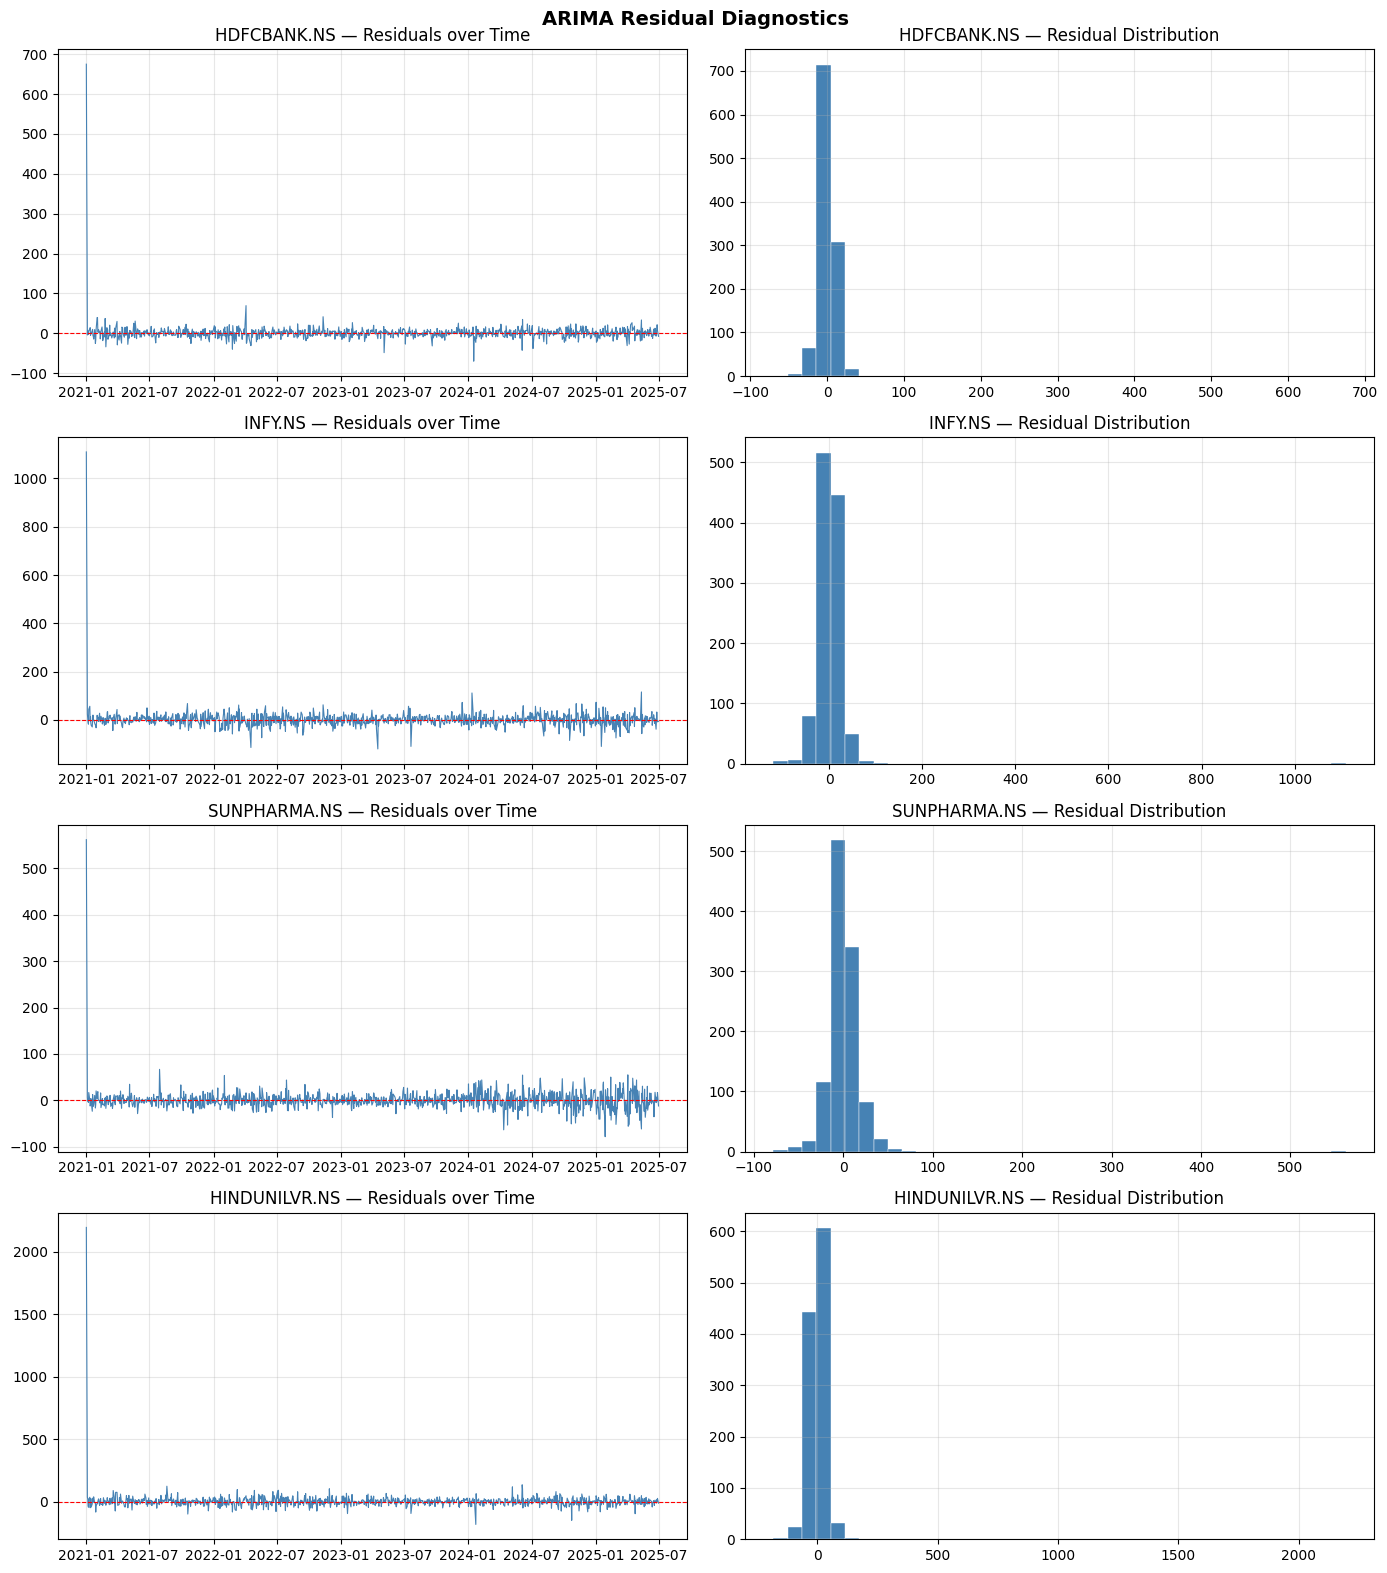

In [9]:
fig, axes = plt.subplots(len(TICKER_LIST), 2, figsize=(14, 4 * len(TICKER_LIST)))

for i, ticker in enumerate(TICKER_LIST):
    residuals = arima_models[ticker].resid()

    axes[i, 0].plot(residuals, linewidth=0.8, color='steelblue')
    axes[i, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[i, 0].set_title(f'{ticker} — Residuals over Time')

    axes[i, 1].hist(residuals, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i, 1].set_title(f'{ticker} — Residual Distribution')

plt.suptitle('ARIMA Residual Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/06_arima_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Predicted vs Actual Plots

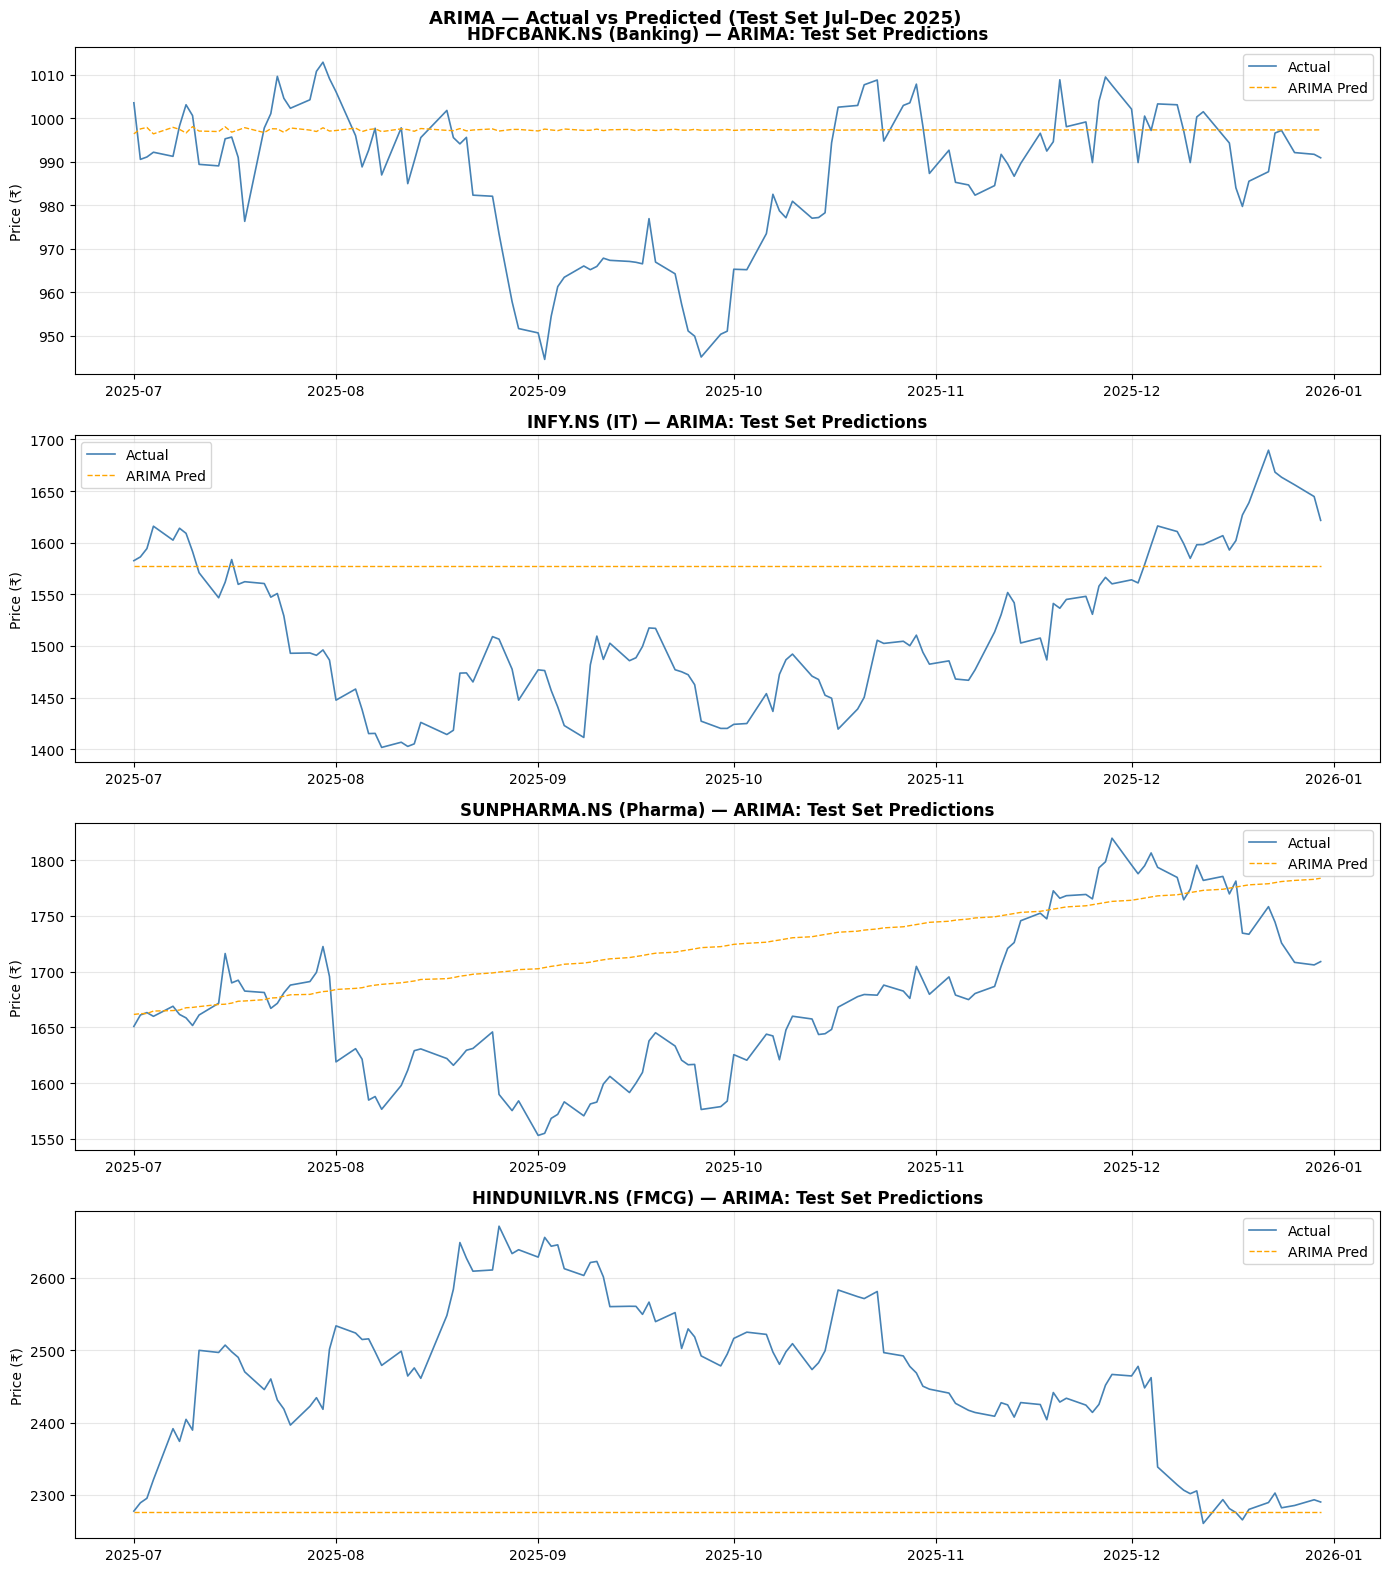

In [10]:
fig, axes = plt.subplots(len(TICKER_LIST), 1, figsize=(14, 4 * len(TICKER_LIST)), sharex=False)

for ax, ticker in zip(axes, TICKER_LIST):
    actual = test_close[ticker].dropna()
    preds  = arima_test_preds[ticker]

    ax.plot(actual.index, actual.values,  label='Actual',    linewidth=1.2, color='steelblue')
    ax.plot(actual.index, preds,          label='ARIMA Pred', linewidth=1.0, color='orange', linestyle='--')
    ax.set_title(f'{ticker} ({SECTOR_MAP[ticker]}) — ARIMA: Test Set Predictions', fontweight='bold')
    ax.set_ylabel('Price (₹)')
    ax.legend()

plt.suptitle('ARIMA — Actual vs Predicted (Test Set Jul–Dec 2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/07_arima_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Metrics Summary Table (Task 6 input)

In [11]:
metrics_df = pd.DataFrame(arima_metrics)
print('ARIMA Evaluation Metrics — Test Set (Jul–Dec 2025)')
print('=' * 65)
print(metrics_df.to_string(index=False))

print(f'\nAverage MAPE    : {metrics_df["MAPE (%)"].mean():.2f}%')
print(f'Average RMSE    : {metrics_df["RMSE"].mean():.2f}')
print(f'Average Dir Acc : {metrics_df["Dir Acc (%)"].mean():.1f}%')

metrics_df.to_csv('../outputs/forecasts/arima_metrics.csv', index=False)

ARIMA Evaluation Metrics — Test Set (Jul–Dec 2025)
        Stock  Sector     Order  MAPE (%)     RMSE  Dir Acc (%)
  HDFCBANK.NS Banking (2, 1, 2)    1.4385  19.5030        47.58
      INFY.NS      IT (0, 1, 0)    5.4058  93.7389         0.81
 SUNPHARMA.NS  Pharma (2, 1, 2)    3.5394  71.7561        58.06
HINDUNILVR.NS    FMCG (0, 1, 0)    7.5580 216.0775         0.00

Average MAPE    : 4.49%
Average RMSE    : 100.27
Average Dir Acc : 26.6%


---
## 7. Live 2-Day Forecast (Beyond Dec 2025)

This is the forecast that drives your StockGro trades.

In [12]:
full_close = pd.concat([train_close, test_close])

live_forecasts = []

for ticker in TICKER_LIST:
    print(f'Forecasting {ticker}...')
    full_series = full_close[ticker].dropna()

    p, d, q = arima_models[ticker].order

    final_model = auto_arima(
        full_series,
        start_p=p, start_q=q,
        max_p=p, max_q=q,
        d=d,
        seasonal=False,
        stepwise=True,
        error_action='ignore',
        suppress_warnings=True
    )

    forecast = np.asarray(final_model.predict(n_periods=FORECAST_HORIZON)).ravel()
    last_price = full_series.iloc[-1]

    live_forecasts.append({
        'Stock'            : ticker,
        'Sector'           : SECTOR_MAP[ticker],
        'Last Known Price' : round(last_price, 2),
        'Forecast Day 1'   : round(forecast[0], 2),
        'Forecast Day 2'   : round(forecast[1], 2),
        'Pred Return D1 (%)': round((forecast[0] - last_price) / last_price * 100, 3),
        'Pred Return D2 (%)': round((forecast[1] - last_price) / last_price * 100, 3)
    })

live_df = pd.DataFrame(live_forecasts)
print('\nLive 2-Day Forecast:')
print(live_df.to_string(index=False))

Forecasting HDFCBANK.NS...


/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Forecasting INFY.NS...
Forecasting SUNPHARMA.NS...
Forecasting HINDUNILVR.NS...

Live 2-Day Forecast:
        Stock  Sector  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS Banking             990.9          991.03          990.59               0.013              -0.031
      INFY.NS      IT            1621.6         1621.60         1621.60               0.000               0.000
 SUNPHARMA.NS  Pharma            1709.1         1711.41         1710.77               0.135               0.098
HINDUNILVR.NS    FMCG            2290.2         2290.20         2290.20               0.000               0.000


/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [13]:
live_df.to_csv('../outputs/forecasts/arima_forecasts.csv', index=False)
print('Saved: outputs/forecasts/arima_forecasts.csv')

Saved: outputs/forecasts/arima_forecasts.csv


---
## 8. Summary

In [14]:
print('=' * 55)
print('NOTEBOOK 02 — ARIMA SUMMARY')
print('=' * 55)

print('\nModel orders selected by auto_arima:')
for ticker in TICKER_LIST:
    print(f'  {ticker:22} → ARIMA{arima_models[ticker].order}')

print('\nTest set performance:')
print(metrics_df[['Stock', 'MAPE (%)', 'RMSE', 'Dir Acc (%)']].to_string(index=False))

print('\nLive 2-day forecast:')
print(live_df[['Stock', 'Forecast Day 1', 'Forecast Day 2', 'Pred Return D1 (%)', 'Pred Return D2 (%)']].to_string(index=False))

print('\nFiles saved:')
print('  outputs/forecasts/arima_forecasts.csv')
print('  outputs/forecasts/arima_metrics.csv')

NOTEBOOK 02 — ARIMA SUMMARY

Model orders selected by auto_arima:
  HDFCBANK.NS            → ARIMA(2, 1, 2)
  INFY.NS                → ARIMA(0, 1, 0)
  SUNPHARMA.NS           → ARIMA(2, 1, 2)
  HINDUNILVR.NS          → ARIMA(0, 1, 0)

Test set performance:
        Stock  MAPE (%)     RMSE  Dir Acc (%)
  HDFCBANK.NS    1.4385  19.5030        47.58
      INFY.NS    5.4058  93.7389         0.81
 SUNPHARMA.NS    3.5394  71.7561        58.06
HINDUNILVR.NS    7.5580 216.0775         0.00

Live 2-day forecast:
        Stock  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS          991.03          990.59               0.013              -0.031
      INFY.NS         1621.60         1621.60               0.000               0.000
 SUNPHARMA.NS         1711.41         1710.77               0.135               0.098
HINDUNILVR.NS         2290.20         2290.20               0.000               0.000

Files saved:
  outputs/forecasts/arima_forecasts.csv
  outpu